# AI-ML Assignment 6

## Weather Condition Classification using Support Vector Machine (SVM) and Open-Meteo API

**Name:** Prathmesh Chedge

**Registration Number:** 23BEC10046

## Objective

Develop an SVM classification model using weather data obtained from the Open-Meteo API to classify weather conditions as Warm or Cool.

# Libraries Used

In [74]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Task 1 : Data Collection and Understanding

In [75]:
latitude = 28.6139
longitude = 77.2090

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    "&start_date=2025-01-01"
    "&end_date=2025-12-31"
    "&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m"
)

response = requests.get(url)
weather = response.json()

In [76]:
hourly = weather["hourly"]

df = pd.DataFrame({
    "Temperature": hourly["temperature_2m"],
    "Humidity": hourly["relative_humidity_2m"],
    "Pressure": hourly["surface_pressure"],
    "Wind_Speed": hourly["wind_speed_10m"]
})

In [77]:
df.head()

,Temperature,Humidity,Pressure,Wind_Speed
0,7.8,97,993.0,7.6
1,8.4,96,993.7,4.3
2,8.5,95,994.2,4.7
3,8.9,93,994.7,6.3
4,9.5,97,995.2,8.7


In [78]:
df.to_csv("weather_data.csv", index=False)

In [79]:
df["Weather_Class"] = df["Temperature"].apply(
    lambda x: "Warm" if x >= 25 else "Cool"
)

In [80]:
df.isnull().sum()

Temperature      0
Humidity         0
Pressure         0
Wind_Speed       0
Weather_Class    0
dtype: int64

In [81]:
encoder = LabelEncoder()

df["Weather_Class"] = encoder.fit_transform(df["Weather_Class"])

In [82]:
df["Weather_Class"].value_counts()

Weather_Class
1    5151
0    3609
Name: count, dtype: int64

# Task 2 : Data Preprocessing

In [83]:
X = df[["Temperature", "Humidity", "Pressure", "Wind_Speed"]]

y = df["Weather_Class"]

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Task 3 : Model Development

In [86]:
model = SVC(kernel="rbf", random_state=42)

In [87]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [88]:
y_pred = model.predict(X_test)

# Task 4 : Model Evaluation

In [89]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-Score :", f1)

Accuracy : 0.9942922374429224
Precision : 0.9913294797687862
Recall : 0.9990291262135922
F1-Score : 0.995164410058027


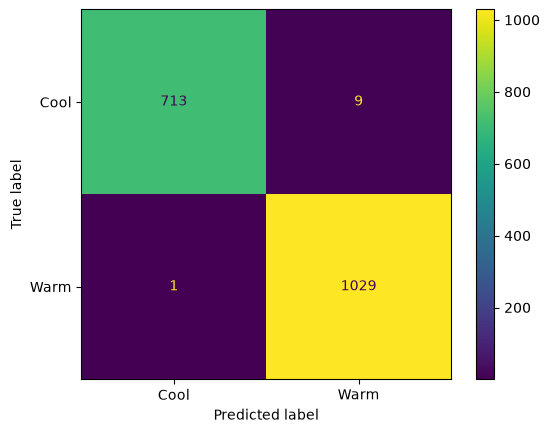

In [90]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

display.plot()

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

## Observations

1. The SVM classifier achieved good classification performance.
2. Feature scaling improved the performance of the SVM model.
3. The confusion matrix shows that most weather records were classified correctly.

# Task 5 : Conclusion

The weather data collected from the Open-Meteo API was used to classify weather conditions into Warm and Cool categories using a Support Vector Machine with an RBF kernel. After preprocessing and feature scaling, the model was trained and evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. The results show that SVM can effectively classify weather conditions. Feature scaling is important because SVM is sensitive to differences in feature scales. An advantage of SVM is its strong performance on classification problems, while a limitation is that it can require more computation on large datasets.